In [1]:
import pandas as pd
import os
import kagglehub
import matplotlib.pyplot as plt
path = kagglehub.dataset_download("zusmani/rainfall-in-pakistan")
print("Path to dataset files:", path)
# Load dataset
path = "/kaggle/input/datasets/zusmani/rainfall-in-pakistan"
file_path = os.path.join(path, os.listdir(path)[0])

df = pd.read_csv(file_path)

# Cleaning
df.columns = df.columns.str.strip()
df = df.rename(columns={'Rainfall - (MM)': 'rainfall'})
df['Month'] = pd.to_datetime(df['Month'], format='%B').dt.month
df['date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))
df = df.sort_values('date')

Path to dataset files: /kaggle/input/datasets/zusmani/rainfall-in-pakistan


In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Feature Engineering
import numpy as np

# Seasonality (already good)
df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df['rain_3month_avg'] = df['rainfall'].rolling(3).mean()
df['rain_6month_avg'] = df['rainfall'].rolling(6).mean()
df['lag1'] = df['rainfall'].shift(1)
df['lag2'] = df['rainfall'].shift(2)
df['spike'] = df['rainfall'] / (df['rain_3month_avg'] + 1)

df['rolling_std_3'] = df['rainfall'].rolling(3).std()
df['rolling_max_3'] = df['rainfall'].rolling(3).max()
df['diff'] = df['rainfall'].diff()
df['heavy_rain'] = (df['rainfall'] > df['rainfall'].quantile(0.75)).astype(int)

# Drop NaNs AFTER everything
df = df.dropna()

In [4]:
# Flood Risk Index (FRI)
df['FRI'] = (df['rainfall'] - df['rain_6month_avg']) / (df['rain_6month_avg'] + 0.001)

In [5]:
# Target


# Create flood risk categories using FRI
low = df['FRI'].quantile(0.33)
high = df['FRI'].quantile(0.66)

def classify_flood(x):
    if x < low:
        return 0   # Low Risk
    elif x < high:
        return 1   # Medium Risk
    else:
        return 2   # High Risk

df['flood_risk'] = df['FRI'].apply(classify_flood)

# Shift target → predict FUTURE flood risk
df['flood_risk_future'] = df['flood_risk'].shift(-1)
print(df['flood_risk_future'].value_counts(normalize=True))
df['flood_binary'] = (df['FRI'] > df['FRI'].quantile(0.66)).astype(int)
df['flood_binary_future'] = df['flood_binary'].shift(-1)
# Drop NaNs after shifting
df = df.dropna()

flood_risk_future
2.0    0.340548
1.0    0.329726
0.0    0.329726
Name: proportion, dtype: float64


In [6]:
# Modeling

X = df[[
    'rainfall',
    'rain_3month_avg',
    'rain_6month_avg',
    'lag1',
    'lag2',
    'spike',
    'rolling_std_3',
    'diff',
]]
y = df['flood_binary_future']

# ==============================
# TIME-BASED SPLIT (IMPORTANT)
# ==============================

train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [7]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print("Logistic Regression:")
print(classification_report(y_test, lr.predict(X_test)))

Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.72      0.89      0.79       177
         1.0       0.67      0.40      0.50       101

    accuracy                           0.71       278
   macro avg       0.69      0.64      0.65       278
weighted avg       0.70      0.71      0.69       278



In [8]:
# ==============================
# MODEL (Random Forest)
# ==============================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train, y_train)
# ==============================
# EVALUATION
# ==============================

from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# ✅ ADD BELOW THIS

train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


from sklearn.metrics import f1_score
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.7122302158273381

Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.73      0.76       177
         1.0       0.59      0.68      0.63       101

    accuracy                           0.71       278
   macro avg       0.70      0.71      0.70       278
weighted avg       0.72      0.71      0.72       278

Train Accuracy: 0.7644404332129964
Test Accuracy: 0.7122302158273381
F1 Score: 0.7159794557275302


In [9]:
# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf.predict(X_test)))

Confusion Matrix:
[[129  48]
 [ 32  69]]


In [10]:
# Cross-validation
scores = cross_val_score(rf, X, y, cv=5)
print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.6840194270576319


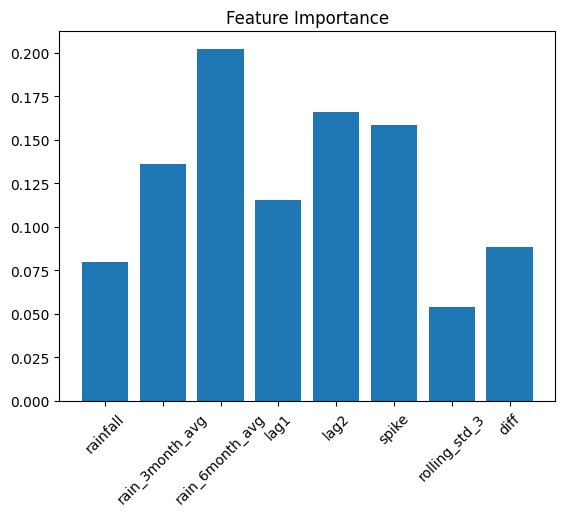

In [11]:
# Feature Importance
plt.figure()
plt.bar(X.columns, rf.feature_importances_)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

In [12]:
# ==============================
# FLOOD RISK SCORE (FRS) - FINAL
# ==============================

df_test = df.iloc[train_size:].copy()

# Normalize rainfall factors
rain_norm = df_test['rainfall'] / df_test['rainfall'].max()
avg_norm = df_test['rain_3month_avg'] / df_test['rain_3month_avg'].max()
lag_norm = df_test['lag1'] / df_test['lag1'].max()

# Final FRS (physically meaningful)
df_test['FRS'] = (
    0.6 * rain_norm +      # MOST IMPORTANT (current rain)
    0.25 * avg_norm +      # accumulation
    0.15 * lag_norm        # recent rain
)
def continuous_rain(row):
    if row['lag1'] > 5 and row['lag2'] > 5:
        return "Continuous"
    else:
        return "No"

df_test['Continuous_Rain'] = df_test.apply(continuous_rain, axis=1)
def rainfall_category(x):
    if x < 10:
        return "Light"
    elif x < 50:
        return "Moderate"
    else:
        return "Heavy"

df_test['Rainfall_mm'] = df_test['rainfall']
df_test['Rainfall_Type'] = df_test['Rainfall_mm'].apply(rainfall_category)
df_test['FRS_percent'] = (df_test['FRS'] * 100).round(2)

df_output = df_test[
    ['Rainfall_mm', 'Rainfall_Type', 'Continuous_Rain', 'FRS', 'FRS_percent']
].copy()

df_output['FRS'] = df_output['FRS'].round(2)
df_output['FRS_percent'] = df_output['FRS_percent'].astype(str) + '%'

print(df_output.head().to_string(index=False, col_space=15))

    Rainfall_mm   Rainfall_Type Continuous_Rain             FRS     FRS_percent
        2.95508           Light      Continuous            0.07           7.15%
        9.43055           Light              No            0.08           8.28%
        0.80544           Light              No            0.03           2.95%
       19.55920        Moderate              No            0.13          13.13%
       29.19290        Moderate              No            0.22          22.46%


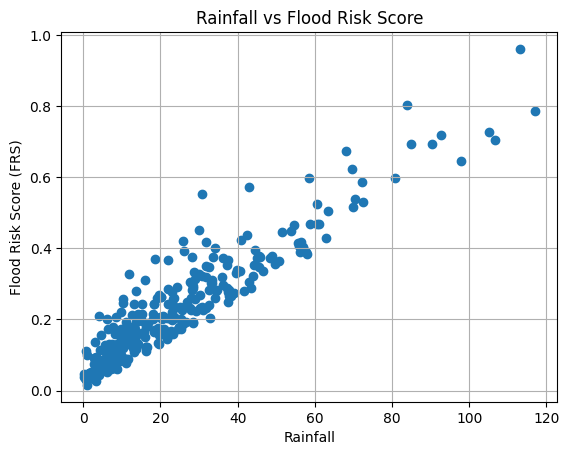

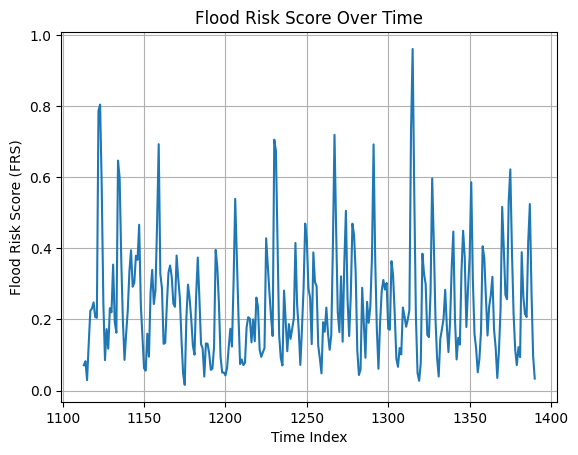

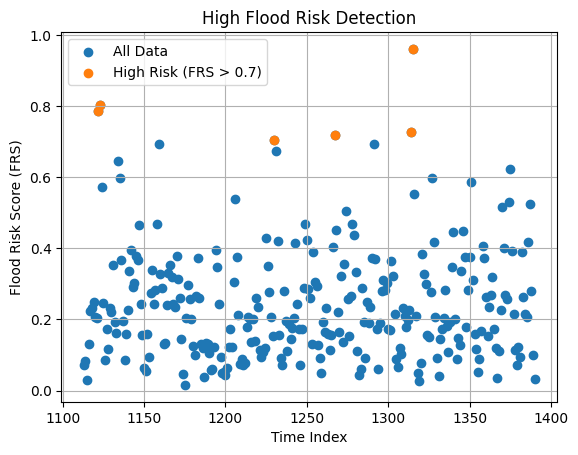

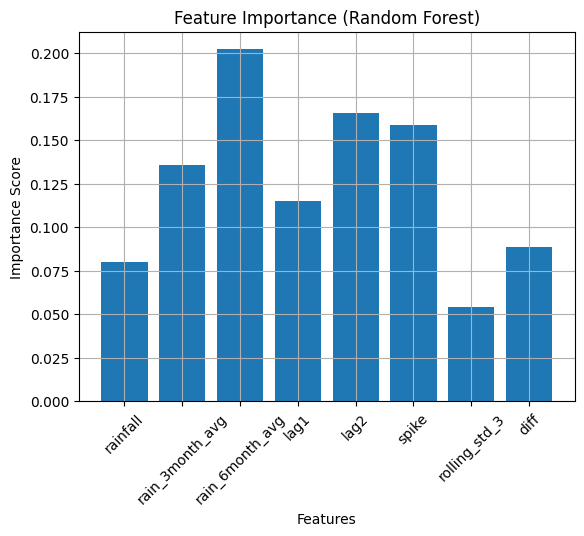

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# Plot 1: Scatter Plot (Rainfall vs Flood Risk Score)
# ==============================
plt.figure()
plt.scatter(df_test['rainfall'], df_test['FRS'])
plt.xlabel("Rainfall")
plt.ylabel("Flood Risk Score (FRS)")
plt.title("Rainfall vs Flood Risk Score")
plt.grid()
plt.show()


# ==============================
# Plot 2: Time Series Plot (Flood Risk Score over Time)
# ==============================
plt.figure()
plt.plot(df_test.index, df_test['FRS'])
plt.xlabel("Time Index")
plt.ylabel("Flood Risk Score (FRS)")
plt.title("Flood Risk Score Over Time")
plt.grid()
plt.show()


# ==============================
# Plot 3: Highlight High Risk Points (FRS > 0.7)
# ==============================
plt.figure()
plt.scatter(df_test.index, df_test['FRS'], label="All Data")
plt.scatter(
    df_test.index[df_test['FRS'] > 0.7],
    df_test['FRS'][df_test['FRS'] > 0.7],
    label="High Risk (FRS > 0.7)"
)
plt.xlabel("Time Index")
plt.ylabel("Flood Risk Score (FRS)")
plt.title("High Flood Risk Detection")
plt.legend()
plt.grid()
plt.show()


# ==============================
# Plot 4: Feature Importance (Random Forest)
# ==============================
plt.figure()
plt.bar(X.columns, rf.feature_importances_)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance (Random Forest)")
plt.xticks(rotation=45)
plt.grid()
plt.show()